# Pemetaan Biner Dataset Lesi Kulit (HAM10000, ISIC 2017, ISIC 2019)
Notebook ini melakukan standardisasi dan pemetaan label diagnosis menjadi 2 kelas: **Benign (0)** dan **Malignant (1)** berdasarkan 1 paper rujukan utama per dataset dan voting literatur.

## 1. Setup & Load Dataset
Inisialisasi library, konfigurasi folder, dan load file gambar serta metadata CSV (HAM10000, ISIC 2017, ISIC 2019).

In [1]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# Deteksi root folder dataset
folder_aktif = os.getcwd()
if os.path.exists(os.path.join(folder_aktif, 'Dataset')):
    ROOT = os.path.join(folder_aktif, 'Dataset')
elif os.path.exists(os.path.join(os.path.dirname(folder_aktif), 'Dataset')):
    ROOT = os.path.join(os.path.dirname(folder_aktif), 'Dataset')
else:
    ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

print(f"Dataset root: {ROOT}")

# Konfigurasi dataset
SOURCES = {
    'ham10000': {
        'year': '2018', 'split': 'train', 'gt_format': 'ham_dx',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
    },
    'isic_2019_train': {
        'year': '2019', 'split': 'train', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv'),
    },
    'isic_2019_test': {
        'year': '2019', 'split': 'test', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_GroundTruth.csv'),
    },
    'isic_2017_train': {
        'year': '2017', 'split': 'train', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
    },
    'isic_2017_val': {
        'year': '2017', 'split': 'val', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
    },
    'isic_2017_test': {
        'year': '2017', 'split': 'test', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
    },
}

print(f"Total dataset sumber: {len(SOURCES)}")


Dataset root: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset
Total dataset sumber: 6


In [2]:
# 1. Scan file gambar fisik (.jpg / .jpeg)
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(d, f)
                        })
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(root_dir, f)
                        })

df_images = pd.DataFrame(all_images)

# 2. Load ground truth CSV dan ekstrak label asli
ground_truth_dfs = {}
label_maps = {}

for source, info in SOURCES.items():
    p = info.get('gt_path')
    fmt = info.get('gt_format')
    if not p or not os.path.exists(p):
        continue
    
    df_gt = pd.read_csv(p)
    id_col = None
    for c in ['image_id', 'image', 'image_name', 'isic_id']:
        if c in df_gt.columns:
            id_col = c
            break
    if id_col is None:
        id_col = df_gt.columns[0]
        
    df_gt['image_id'] = df_gt[id_col].astype(str).str.replace('.jpg', '', regex=False)
    ground_truth_dfs[source] = df_gt
    
    if fmt == 'ham_dx':
        for _, row in df_gt.iterrows():
            label_maps[row['image_id']] = str(row['dx']).lower()
    elif fmt == '2017':
        for _, row in df_gt.iterrows():
            if row.get('melanoma') == 1.0:
                label_maps[row['image_id']] = 'melanoma'
            elif row.get('seborrheic_keratosis') == 1.0:
                label_maps[row['image_id']] = 'seborrheic_keratosis'
            else:
                label_maps[row['image_id']] = 'nevus'
    elif fmt == 'onehot9':
        cols = [c for c in df_gt.columns if c not in ('image_id', id_col, 'score_weight', 'validation_weight')]
        for _, row in df_gt.iterrows():
            assigned = None
            for c in cols:
                if row.get(c) == 1.0:
                    assigned = c
                    break
            if assigned:
                label_maps[row['image_id']] = assigned

df_images['original_label'] = df_images['image_id'].map(label_maps)

print(f"Gambar fisik terindeks : {len(df_images):,}")
print(f"Gambar berlabel CSV     : {df_images['original_label'].notna().sum():,}")


Gambar fisik terindeks : 46,334
Gambar berlabel CSV     : 46,334


## 2. Deduplikasi Data (Prioritas HAM10000)
Menghapus gambar duplikat di ISIC 2019 dan 2017 dengan mempertahankan dataset HAM10000.

In [3]:
# Prioritas dataset: HAM10000 dipertahankan
PRIORITY_ORDER = [
    'ham10000',
    'isic_2019_train',
    'isic_2019_test',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test'
]

priority_map = {src: i for i, src in enumerate(PRIORITY_ORDER)}
df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_map)

# Hapus duplikat berdasarkan image_id
df_sorted = df_all.sort_values(by=['image_id', 'priority'])
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').copy()
df_dropped = df_sorted[~df_sorted.index.isin(df_clean.index)].copy()

# Petakan sumber yang mempertahankan gambar
kept_map = df_clean.set_index('image_id')['source'].to_dict()
df_dropped['kept_in_source'] = df_dropped['image_id'].map(kept_map)

# Ringkasan sebelum vs sesudah
before_counts = df_all['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_summary = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct = round((d / b * 100), 2) if b > 0 else 0
    
    dropped_src = df_dropped[df_dropped['source'] == src]
    if len(dropped_src) > 0:
        detail = "; ".join([f"{k} ({v:,})" for k, v in dropped_src['kept_in_source'].value_counts().items()])
    else:
        detail = "-"
        
    rows_summary.append({
        'Source': src,
        'Before': b,
        'Dropped': d,
        'After': a,
        '% Drop': f"{pct}%",
        'Kept In': detail
    })

df_dedup_summary = pd.DataFrame(rows_summary)
display(df_dedup_summary)

print(f"Total awal    : {len(df_all):,} citra")
print(f"Duplikat      : {len(df_dropped):,} citra")
print(f"Setelah bersih: {len(df_clean):,} citra")


Total awal    : 46,334 citra
Duplikat      : 10,735 citra
Setelah bersih: 35,599 citra


,Source,Before,Dropped,After,% Drop,Kept In
0,ham10000,10015,0,10015,0.0%,-
1,isic_2019_train,25331,10015,15316,39.54%,"ham10000 (10,015)"
2,isic_2019_test,8238,0,8238,0.0%,-
3,isic_2017_train,2000,717,1283,35.85%,isic_2019_train (717)
4,isic_2017_val,150,2,148,1.33%,isic_2019_train (2)
5,isic_2017_test,600,1,599,0.17%,isic_2019_train (1)


## 3. Distribusi Label Asli
Melihat sebaran dan frekuensi kelas diagnosis asli pada data bersih sebelum pemetaan biner.

In [4]:
# Keterangan diagnosis medis
DIAGNOSIS_MAP = {
    'nv': ('Melanocytic Nevus', 'Tahi lalat jinak'),
    'bkl': ('Benign Keratosis', 'Keratosis seboroik jinak'),
    'df': ('Dermatofibroma', 'Nodul jinak kulit'),
    'vasc': ('Vascular Lesion', 'Lesi vaskular jinak'),
    'mel': ('Melanoma', 'Kanker kulit ganas (melanosit)'),
    'bcc': ('Basal Cell Carcinoma', 'Kanker kulit ganas (sel basal)'),
    'akiec': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik'),
    'ak': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik'),
    'scc': ('Squamous Cell Carcinoma', 'Kanker kulit ganas (sel skuamosa)'),
    'nevus': ('Melanocytic Nevus', 'Tahi lalat jinak'),
    'seborrheic_keratosis': ('Seborrheic Keratosis', 'Keratosis seboroik jinak'),
    'melanoma': ('Melanoma', 'Kanker kulit ganas (melanosit)'),
    'unk': ('Unknown', 'Label tidak teridentifikasi')
}

df_labeled = df_clean[df_clean['original_label'].notna()].copy()
df_labeled['std_label'] = df_labeled['original_label'].astype(str).str.lower()

freq = df_labeled['std_label'].value_counts()
rows_diag = []
for lbl, cnt in freq.items():
    name, desc = DIAGNOSIS_MAP.get(lbl, (lbl.upper(), '-'))
    rows_diag.append({
        'Label': lbl,
        'Diagnosis': name,
        'Keterangan': desc,
        'Jumlah': cnt,
        'Proporsi': f"{cnt / len(df_labeled) * 100:.2f}%"
    })

df_diag_summary = pd.DataFrame(rows_diag)
display(df_diag_summary)


,Label,Diagnosis,Keterangan,Jumlah,Proporsi
0,nv,Melanocytic Nevus,Tahi lalat jinak,14800,41.57%
1,mel,Melanoma,Kanker kulit ganas (melanosit),5701,16.01%
2,bcc,Basal Cell Carcinoma,Kanker kulit ganas (sel basal),4298,12.07%
3,bkl,Benign Keratosis,Keratosis seboroik jinak,3282,9.22%
4,unk,Unknown,Label tidak teridentifikasi,2047,5.75%
5,nevus,Melanocytic Nevus,Tahi lalat jinak,1843,5.18%
6,ak,Actinic Keratosis,Lesi pra-kanker keratinositik,1241,3.49%
7,scc,Squamous Cell Carcinoma,Kanker kulit ganas (sel skuamosa),793,2.23%
8,melanoma,Melanoma,Kanker kulit ganas (melanosit),521,1.46%
9,seborrheic_keratosis,Seborrheic Keratosis,Keratosis seboroik jinak,386,1.08%


## 4. Rujukan Paper & Konsensus Voting
Pemetaan biner mengacu pada 1 paper utama per dataset, didukung voting dari seluruh literatur:
1. **ISIC 2017:** Catarina Barata et al. (Elsevier Pattern Recognition 2020)
2. **HAM10000:** Ioannis Kousis et al. (MDPI Electronics 2022) & SkinNet-16 (Frontiers 2022)
3. **ISIC 2019:** MorphoNet / Bradley Yao et al. (MDPI Bioengineering 2026)

In [5]:
# 1. Paper acuan utama per dataset
df_main_ref = pd.DataFrame([
    {
        'Dataset': 'ISIC 2017',
        'Paper Rujukan': 'Catarina Barata et al. (2020)',
        'Jurnal / Publisher': 'Pattern Recognition (Elsevier Q1)',
        'Benign (0)': 'nevus, seborrheic_keratosis',
        'Malignant (1)': 'melanoma'
    },
    {
        'Dataset': 'HAM10000',
        'Paper Rujukan': 'Ioannis Kousis et al. (2022)',
        'Jurnal / Publisher': 'Electronics (MDPI) / Frontiers',
        'Benign (0)': 'nv, bkl, df, vasc',
        'Malignant (1)': 'mel, bcc, akiec'
    },
    {
        'Dataset': 'ISIC 2019',
        'Paper Rujukan': 'MorphoNet / Yao et al. (2026)',
        'Jurnal / Publisher': 'Bioengineering (MDPI)',
        'Benign (0)': 'NV, BKL, DF, VASC',
        'Malignant (1)': 'MEL, BCC, AKIEC, SCC'
    }
])
display(df_main_ref)

# 2. Rekap literatur pendukung
df_lit = pd.DataFrame([
    {'Dataset': 'ISIC 2017', 'Paper': 'Barata et al. (2020)', 'Penerbit': 'Elsevier', 'Benign': 'nevus, seborrheic_keratosis', 'Malignant': 'melanoma'},
    {'Dataset': 'ISIC 2017', 'Paper': 'Jojoa Acosta et al. (2021)', 'Penerbit': 'Springer', 'Benign': 'Nevus, Seborrheic Keratosis', 'Malignant': 'Melanoma'},
    {'Dataset': 'HAM10000', 'Paper': 'Harangi et al. (2020)', 'Penerbit': 'Elsevier', 'Benign': 'bkl, df, nv', 'Malignant': 'mel, bcc, akiec, vasc*'},
    {'Dataset': 'HAM10000', 'Paper': 'Kousis et al. (2022)', 'Penerbit': 'MDPI', 'Benign': 'nv, bkl, vasc, df', 'Malignant': 'mel, bcc, akiec'},
    {'Dataset': 'HAM10000', 'Paper': 'SkinNet-16 / Ghosh (2022)', 'Penerbit': 'Frontiers', 'Benign': 'df, bkl, vasc, nv', 'Malignant': 'bcc, mel, akiec'},
    {'Dataset': 'HAM10000', 'Paper': 'Ameri (2020)', 'Penerbit': 'JBPE', 'Benign': 'df, nv, bkl', 'Malignant': 'mel, bcc, akiec (vasc exclude)'},
    {'Dataset': 'ISIC 2019', 'Paper': 'MorphoNet / Yao (2026)', 'Penerbit': 'MDPI', 'Benign': 'NV, BKL, DF, VASC', 'Malignant': 'MEL, BCC, AKIEC, SCC'},
    {'Dataset': 'ISIC 2019', 'Paper': 'Venugopal et al. (2023)', 'Penerbit': 'Elsevier', 'Benign': 'NV, BKL, AK*, UNK', 'Malignant': 'MEL, BCC, SCC'}
])
display(df_lit)

# 3. Hasil voting & justifikasi medis
df_voting = pd.DataFrame([
    {'Kelas': 'NV / nevus', 'Suara Benign': '8 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Tahi lalat biasa (non-kanker)'},
    {'Kelas': 'BKL / keratosis', 'Suara Benign': '8 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Keratosis seboroik jinak'},
    {'Kelas': 'DF', 'Suara Benign': '5 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Dermatofibroma jinak'},
    {'Kelas': 'VASC', 'Suara Benign': '4 (80%)', 'Suara Malignant': '1 (20%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Lesi vaskular jinak (cherry angioma/hemangioma)'},
    {'Kelas': 'MEL / melanoma', 'Suara Benign': '0 (0%)', 'Suara Malignant': '8 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Kanker melanoma ganas'},
    {'Kelas': 'BCC', 'Suara Benign': '0 (0%)', 'Suara Malignant': '6 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Karsinoma sel basal ganas'},
    {'Kelas': 'SCC', 'Suara Benign': '0 (0%)', 'Suara Malignant': '2 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Karsinoma sel skuamosa ganas'},
    {'Kelas': 'AKIEC / AK', 'Suara Benign': '1 (17%)', 'Suara Malignant': '5 (83%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Lesi pra-kanker (Bowen disease / karsinoma in situ)'}
])
display(df_voting)


,Dataset,Paper Rujukan,Jurnal / Publisher,Benign (0),Malignant (1)
0,ISIC 2017,Catarina Barata et al. (2020),Pattern Recognition (Elsevier Q1),"nevus, seborrheic_keratosis",melanoma
1,HAM10000,Ioannis Kousis et al. (2022),Electronics (MDPI) / Frontiers,"nv, bkl, df, vasc","mel, bcc, akiec"
2,ISIC 2019,MorphoNet / Yao et al. (2026),Bioengineering (MDPI),"NV, BKL, DF, VASC","MEL, BCC, AKIEC, SCC"


,Dataset,Paper,Penerbit,Benign,Malignant
0,ISIC 2017,Barata et al. (2020),Elsevier,"nevus, seborrheic_keratosis",melanoma
1,ISIC 2017,Jojoa Acosta et al. (2021),Springer,"Nevus, Seborrheic Keratosis",Melanoma
2,HAM10000,Harangi et al. (2020),Elsevier,"bkl, df, nv","mel, bcc, akiec, vasc*"
3,HAM10000,Kousis et al. (2022),MDPI,"nv, bkl, vasc, df","mel, bcc, akiec"
4,HAM10000,SkinNet-16 / Ghosh (2022),Frontiers,"df, bkl, vasc, nv","bcc, mel, akiec"
5,HAM10000,Ameri (2020),JBPE,"df, nv, bkl","mel, bcc, akiec (vasc exclude)"
6,ISIC 2019,MorphoNet / Yao (2026),MDPI,"NV, BKL, DF, VASC","MEL, BCC, AKIEC, SCC"
7,ISIC 2019,Venugopal et al. (2023),Elsevier,"NV, BKL, AK*, UNK","MEL, BCC, SCC"


,Kelas,Suara Benign,Suara Malignant,Target,Catatan Medis
0,NV / nevus,8 (100%),0 (0%),Benign (0),Tahi lalat biasa (non-kanker)
1,BKL / keratosis,8 (100%),0 (0%),Benign (0),Keratosis seboroik jinak
2,DF,5 (100%),0 (0%),Benign (0),Dermatofibroma jinak
3,VASC,4 (80%),1 (20%),Benign (0),Lesi vaskular jinak (cherry angioma/hemangioma)
4,MEL / melanoma,0 (0%),8 (100%),Malignant (1),Kanker melanoma ganas
5,BCC,0 (0%),6 (100%),Malignant (1),Karsinoma sel basal ganas
6,SCC,0 (0%),2 (100%),Malignant (1),Karsinoma sel skuamosa ganas
7,AKIEC / AK,1 (17%),5 (83%),Malignant (1),Lesi pra-kanker (Bowen disease / karsinoma in situ)


## 5. Mapping Rules
Kamus pemetaan biner:
- **Benign (0):** `nv`, `nevus`, `bkl`, `seborrheic_keratosis`, `df`, `vasc`
- **Malignant (1):** `mel`, `melanoma`, `bcc`, `scc`, `akiec`, `ak`

In [6]:
# Kamus aturan biner
BINARY_RULES = {
    'nv': 0, 'nevus': 0, 'bkl': 0, 'seborrheic_keratosis': 0, 'df': 0, 'vasc': 0,
    'mel': 1, 'melanoma': 1, 'bcc': 1, 'scc': 1, 'akiec': 1, 'ak': 1
}

BINARY_NAMES = {0: 'Benign', 1: 'Malignant'}

for k, v in BINARY_RULES.items():
    print(f"{k:<22} -> {BINARY_NAMES[v]} ({v})")


nv                     -> Benign (0)
nevus                  -> Benign (0)
bkl                    -> Benign (0)
seborrheic_keratosis   -> Benign (0)
df                     -> Benign (0)
vasc                   -> Benign (0)
mel                    -> Malignant (1)
melanoma               -> Malignant (1)
bcc                    -> Malignant (1)
scc                    -> Malignant (1)
akiec                  -> Malignant (1)
ak                     -> Malignant (1)


## 6. Eksekusi Pemetaan Biner
Menerapkan aturan pemetaan pada dataset dan membuang sampel tanpa label pasti (`unk`).

In [7]:
# Terapkan mapping biner
df_binary = df_labeled.copy()
df_binary['target_binary'] = df_binary['std_label'].map(BINARY_RULES)
df_binary['binary_class'] = df_binary['target_binary'].map(BINARY_NAMES)

# Drop data unk (out of distribution)
n_unk = df_binary['target_binary'].isna().sum()
if n_unk > 0:
    print(f"Data 'unk' di-drop : {n_unk:,} sampel")
    df_binary = df_binary.dropna(subset=['target_binary']).copy()

df_binary['target_binary'] = df_binary['target_binary'].astype(int)

print(f'Total data valid   : {len(df_binary):,}')
print(f'- Benign (0)       : {(df_binary["target_binary"] == 0).sum():,}')
print(f'- Malignant (1)    : {(df_binary["target_binary"] == 1).sum():,}')
print(f'- Missing target   : {df_binary["target_binary"].isna().sum()}')

display(df_binary[['image_id', 'source', 'original_label', 'binary_class', 'target_binary']].head(10))


Data 'unk' di-drop : 2,047 sampel
Total data valid   : 33,552
- Benign (0)       : 20,998
- Malignant (1)    : 12,554
- Missing target   : 0


,image_id,source,original_label,binary_class,target_binary
10015,ISIC_0000000,isic_2019_train,nevus,Benign,0
10016,ISIC_0000001,isic_2019_train,nevus,Benign,0
10017,ISIC_0000002,isic_2019_train,melanoma,Malignant,1
10018,ISIC_0000003,isic_2019_train,nevus,Benign,0
10019,ISIC_0000004,isic_2019_train,melanoma,Malignant,1
10020,ISIC_0000006,isic_2019_train,nevus,Benign,0
10021,ISIC_0000007,isic_2019_train,nevus,Benign,0
10022,ISIC_0000008,isic_2019_train,nevus,Benign,0
10023,ISIC_0000009,isic_2019_train,nevus,Benign,0
10024,ISIC_0000010,isic_2019_train,nevus,Benign,0


## 7. Analisis & Visualisasi Distribusi Biner
Melihat perbandingan jumlah Benign vs Malignant per dataset dalam tabel dan visualisasi grafik batang.

In [8]:
# Rekapitulasi per sumber dataset
rekap_rows = []
sources = ['ham10000', 'isic_2019_train', 'isic_2017_train', 'isic_2017_val', 'isic_2017_test']

for src in sources:
    sub = df_binary[df_binary['source'] == src]
    if len(sub) == 0:
        continue
    n_b = int((sub['target_binary'] == 0).sum())
    n_m = int((sub['target_binary'] == 1).sum())
    total = len(sub)
    rekap_rows.append({
        'Source Dataset': src,
        'Total': f"{total:,}",
        'Benign (0)': f"{n_b:,} ({n_b/total*100:.1f}%)",
        'Malignant (1)': f"{n_m:,} ({n_m/total*100:.1f}%)",
        'Rasio B:M': f"{n_b/n_m:.2f} : 1" if n_m > 0 else "-"
    })

tot_b = int((df_binary['target_binary'] == 0).sum())
tot_m = int((df_binary['target_binary'] == 1).sum())
tot = len(df_binary)

rekap_rows.append({
    'Source Dataset': 'TOTAL',
    'Total': f"{tot:,}",
    'Benign (0)': f"{tot_b:,} ({tot_b/tot*100:.1f}%)",
    'Malignant (1)': f"{tot_m:,} ({tot_m/tot*100:.1f}%)",
    'Rasio B:M': f"{tot_b/tot_m:.2f} : 1"
})

df_summary = pd.DataFrame(rekap_rows)
display(df_summary)


,Source Dataset,Total,Benign (0),Malignant (1),Rasio B:M
0,ham10000,"10,015","8,061 (80.5%)","1,954 (19.5%)",4.13 : 1
1,isic_2019_train,"15,316","7,930 (51.8%)","7,386 (48.2%)",1.07 : 1
2,isic_2017_train,"1,283","1,056 (82.3%)",227 (17.7%),4.65 : 1
3,isic_2017_val,148,118 (79.7%),30 (20.3%),3.93 : 1
4,isic_2017_test,599,483 (80.6%),116 (19.4%),4.16 : 1
5,TOTAL,"33,552","20,998 (62.6%)","12,554 (37.4%)",1.67 : 1


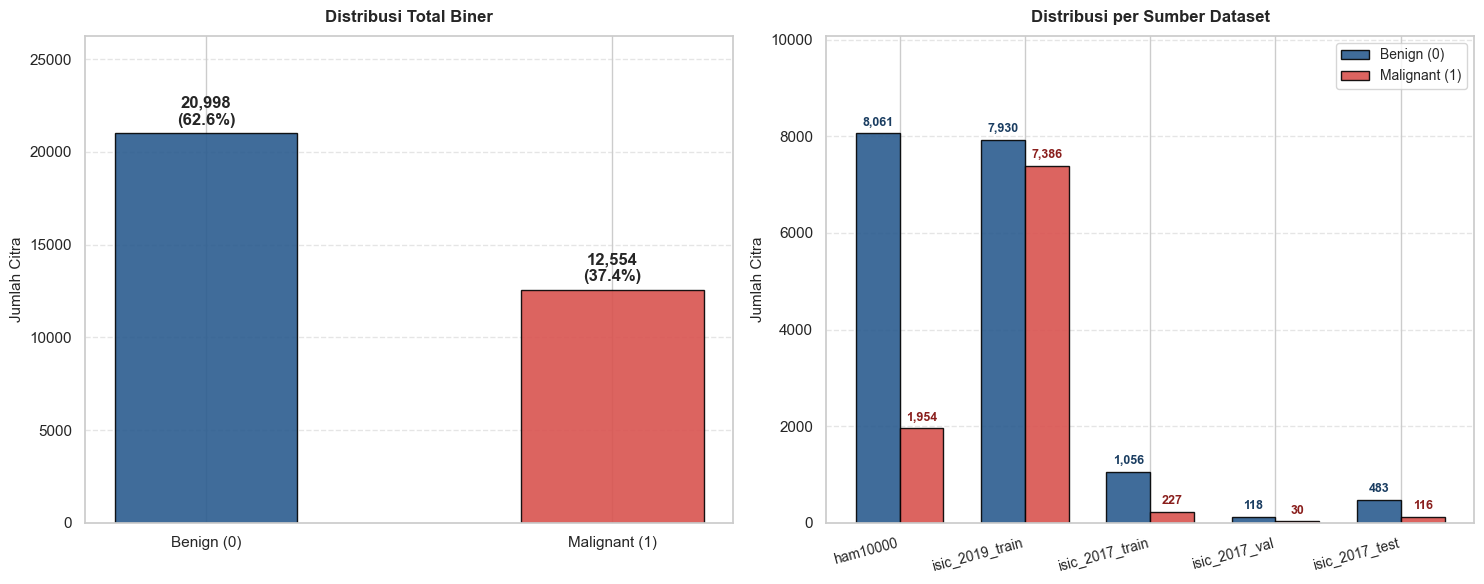

In [9]:
# Visualisasi grafik batang
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Total distribusi biner
ax1 = axes[0]
counts_total = [tot_b, tot_m]
labels_total = ['Benign (0)', 'Malignant (1)']
colors = ['#2b5c8f', '#d9534f']

bars1 = ax1.bar(labels_total, counts_total, color=colors, width=0.45, edgecolor='black', alpha=0.9)
ax1.set_title("Distribusi Total Biner", fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel("Jumlah Citra", fontsize=11)
ax1.set_ylim(0, max(counts_total) * 1.25)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    h = bar.get_height()
    pct = h / tot * 100
    ax1.text(bar.get_x() + bar.get_width()/2.0, h + 300, f"{int(h):,}\n({pct:.1f}%)", ha='center', va='bottom', fontweight='bold')

# 2. Perbandingan per sumber dataset
ax2 = axes[1]
datasets_ordered = [r['Source Dataset'] for r in rekap_rows if r['Source Dataset'] != 'TOTAL']
x = np.arange(len(datasets_ordered))
width = 0.35

b_vals = [(df_binary[(df_binary['source'] == s) & (df_binary['target_binary'] == 0)]).shape[0] for s in datasets_ordered]
m_vals = [(df_binary[(df_binary['source'] == s) & (df_binary['target_binary'] == 1)]).shape[0] for s in datasets_ordered]

rects_b = ax2.bar(x - width/2, b_vals, width=width, label='Benign (0)', color='#2b5c8f', edgecolor='black', alpha=0.9)
rects_m = ax2.bar(x + width/2, m_vals, width=width, label='Malignant (1)', color='#d9534f', edgecolor='black', alpha=0.9)

max_sub = max(max(b_vals), max(m_vals))
ax2.set_ylim(0, max_sub * 1.25)
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_ordered, rotation=15, ha='right', fontsize=10)
ax2.set_ylabel("Jumlah Citra", fontsize=11)
ax2.set_title("Distribusi per Sumber Dataset", fontsize=12, fontweight='bold', pad=10)
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects_b:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + 100, f"{int(h):,}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a3d61')

for rect in rects_m:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + 100, f"{int(h):,}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#8a1f1d')

plt.tight_layout()
plt.show()


## 8. Ekspor Dataset Final
Menyimpan dataset biner bersih ke `dataset_binary_final.csv`.

In [10]:
# Simpan ke CSV
output_csv = os.path.join(ROOT, 'dataset_binary_final.csv')
cols_export = ['image_id', 'source', 'original_label', 'binary_class', 'target_binary', 'filepath']

df_binary[cols_export].to_csv(output_csv, index=False)

print(f"File tersimpan : {output_csv}")
print(f"Total data     : {len(df_binary):,} baris")
print(f"Kolom          : {', '.join(cols_export)}")

display(df_binary[cols_export].head(10))


File tersimpan : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_binary_final.csv
Total data     : 33,552 baris
Kolom          : image_id, source, original_label, binary_class, target_binary, filepath


,image_id,source,original_label,binary_class,target_binary,filepath
10015,ISIC_0000000,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000000.jpg
10016,ISIC_0000001,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000001.jpg
10017,ISIC_0000002,isic_2019_train,melanoma,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000002.jpg
10018,ISIC_0000003,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000003.jpg
10019,ISIC_0000004,isic_2019_train,melanoma,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000004.jpg
10020,ISIC_0000006,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000006.jpg
10021,ISIC_0000007,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000007.jpg
10022,ISIC_0000008,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000008.jpg
10023,ISIC_0000009,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000009.jpg
10024,ISIC_0000010,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000010.jpg


## 9. Sampel Data per Kelas
Menampilkan 5 sampel data untuk masing-masing kelas (Benign dan Malignant), baik dalam bentuk tabel maupun visualisasi gambar.

,image_id,source,original_label,binary_class,target_binary,filepath
0,ISIC_0000000,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000000.jpg
1,ISIC_0000001,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000001.jpg
2,ISIC_0000003,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000003.jpg
3,ISIC_0000006,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000006.jpg
4,ISIC_0000007,isic_2019_train,nevus,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000007.jpg
5,ISIC_0000002,isic_2019_train,melanoma,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000002.jpg
6,ISIC_0000004,isic_2019_train,melanoma,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000004.jpg
7,ISIC_0000013,isic_2019_train,melanoma,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000013.jpg
8,ISIC_0000022,isic_2017_train,melanoma,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2017\ISIC-2017_Training_Data\ISIC-2017_Training_Data\ISIC_0000022.jpg
9,ISIC_0000022_downsampled,isic_2019_train,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000022_downsampled.jpg


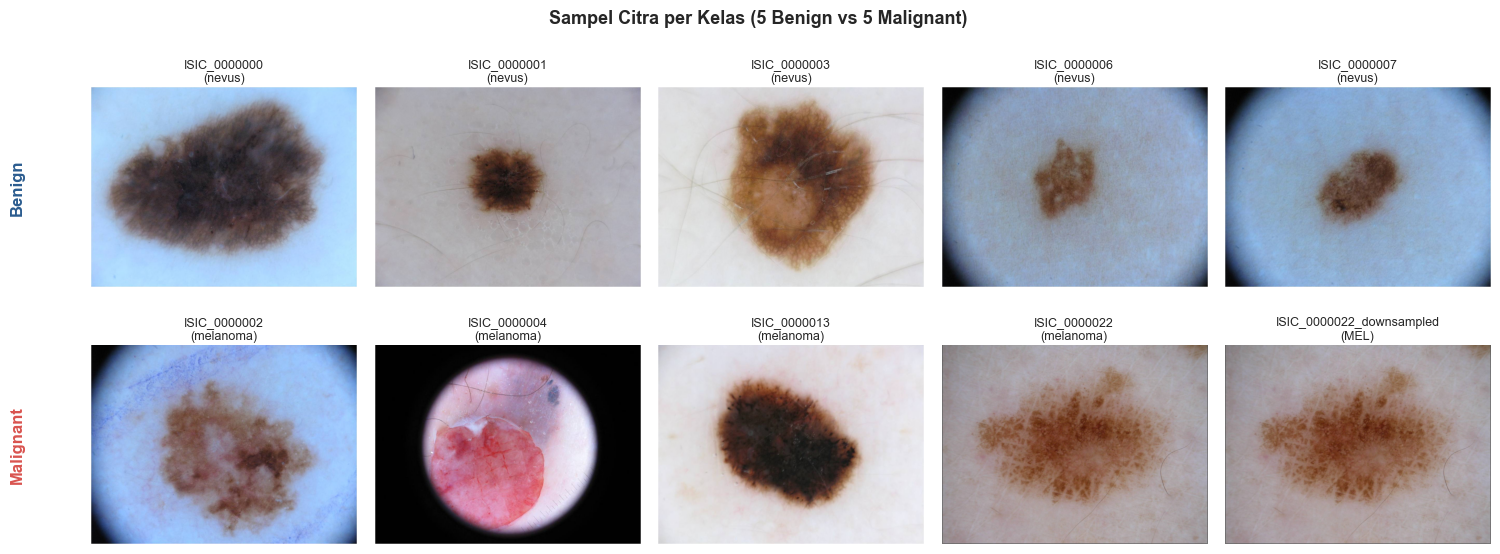

In [11]:
from PIL import Image

# 1. Tabel 5 sampel per kelas biner
sample_b = df_binary[df_binary['binary_class'] == 'Benign'].head(5)
sample_m = df_binary[df_binary['binary_class'] == 'Malignant'].head(5)
df_samples = pd.concat([sample_b, sample_m], ignore_index=True)

cols_show = ['image_id', 'source', 'original_label', 'binary_class', 'target_binary', 'filepath']
display(df_samples[cols_show])

# 2. Visualisasi 5 gambar per kelas (Benign vs Malignant)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row_idx, cls_name in enumerate(['Benign', 'Malignant']):
    subset = df_binary[df_binary['binary_class'] == cls_name].head(5)
    for col_idx, (_, r) in enumerate(subset.iterrows()):
        ax = axes[row_idx, col_idx]
        if os.path.exists(r['filepath']):
            img = Image.open(r['filepath'])
            ax.imshow(img)
        iid = r['image_id']
        lbl = r['original_label']
        ax.set_title(f"{iid}\n({lbl})", fontsize=9, pad=4)
        ax.axis('off')
        if col_idx == 0:
            ax.text(-0.25, 0.5, cls_name, transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='center', ha='right', rotation=90,
                    color='#2b5c8f' if cls_name == 'Benign' else '#d9534f')

plt.suptitle("Sampel Citra per Kelas (5 Benign vs 5 Malignant)", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
